# Week 11-12: Dimensionality Reduction (PCA and t-SNE)

**Task:** study the basic intuition and applications of PCA and t-SNE, and understand how they reduce / visualize high-dimensional data.

Name: Your Name | Roll No: ______

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

## 1. Why reduce dimensions?

Real data often has many columns (features). An image of 8x8 pixels has 64 features, a gene dataset can have thousands.
We cannot plot more than 3 dimensions, so we need a way to squeeze the data into 2D or 3D without losing too much information.

| Problem with many features | How dimensionality reduction helps |
|---|---|
| Cannot visualize it | Project to 2D / 3D and plot |
| Models get slow | Fewer features means faster training |
| Noise and redundant (correlated) features | Keep only the important directions |
| Curse of dimensionality (data becomes sparse) | Work in a smaller, denser space |
| Large storage | Store fewer numbers per row |

## 2. PCA (Principal Component Analysis)

### Intuition
Imagine a cloud of points. PCA finds a **new set of axes** (called principal components):
- **PC1** points in the direction where the data is spread out the most (maximum variance)
- **PC2** is perpendicular to PC1 and captures the most of the remaining variance
- and so on

Then we keep only the first few components. Directions with small variance carry little information, so dropping them loses little.

### Steps
1. Standardize the data (mean 0, std 1) so no feature dominates because of its units
2. Find the directions of maximum variance (eigenvectors of the covariance matrix)
3. Sort them by variance (eigenvalue)
4. Project the data onto the top k directions

PCA is **linear** (only rotates and projects), **fast**, and the same transformation can be applied to new data.

### A tiny example in 2D
The points below lie along a diagonal, so one direction (PC1) explains most of the spread.

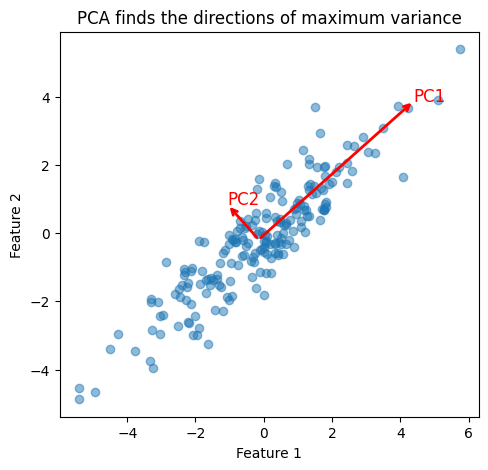

Variance explained by PC1: 95.2 %
Variance explained by PC2: 4.8 %


In [2]:
rng = np.random.default_rng(1)
x = rng.normal(0, 2, 200)
y = 0.8 * x + rng.normal(0, 0.8, 200)
toy = np.c_[x, y]

pca_toy = PCA(n_components=2).fit(toy)
center = toy.mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(toy[:, 0], toy[:, 1], alpha=0.5)
for i, (vec, var) in enumerate(zip(pca_toy.components_, pca_toy.explained_variance_), start=1):
    end = center + vec * 2.5 * np.sqrt(var)
    ax.annotate("", xy=end, xytext=center, arrowprops=dict(arrowstyle="->", color="red", lw=2))
    ax.text(end[0], end[1], f"PC{i}", color="red", fontsize=12)
ax.set_aspect("equal"); ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
ax.set_title("PCA finds the directions of maximum variance")
plt.show()

print("Variance explained by PC1:", round(pca_toy.explained_variance_ratio_[0] * 100, 1), "%")
print("Variance explained by PC2:", round(pca_toy.explained_variance_ratio_[1] * 100, 1), "%")

If we keep only PC1, we turn 2 features into 1 and still keep most of the information.

### PCA on the Iris dataset (4 features -> 2)
Iris has 150 flowers with 4 measurements each (sepal length/width, petal length/width) and 3 species.

In [3]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_iris_scaled = StandardScaler().fit_transform(X_iris)      # step 1: standardize

pca_iris = PCA().fit(X_iris_scaled)
var_table = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(4)],
    "Explained variance %": (pca_iris.explained_variance_ratio_ * 100).round(1),
    "Cumulative %": (np.cumsum(pca_iris.explained_variance_ratio_) * 100).round(1)})
var_table

,Component,Explained variance %,Cumulative %
0,PC1,73.0,73.0
1,PC2,22.9,95.8
2,PC3,3.7,99.5
3,PC4,0.5,100.0


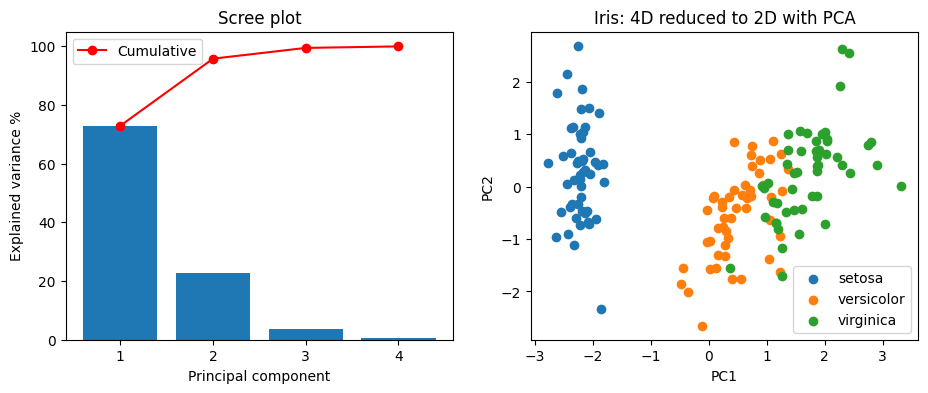

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# scree plot: how much variance each component explains
axes[0].bar(range(1, 5), pca_iris.explained_variance_ratio_ * 100)
axes[0].plot(range(1, 5), np.cumsum(pca_iris.explained_variance_ratio_) * 100, "o-", color="red", label="Cumulative")
axes[0].set_xticks(range(1, 5)); axes[0].set_xlabel("Principal component"); axes[0].set_ylabel("Explained variance %")
axes[0].set_title("Scree plot"); axes[0].legend()

# the data in 2D
X_iris_2d = PCA(n_components=2).fit_transform(X_iris_scaled)
for label, name in enumerate(iris.target_names):
    axes[1].scatter(X_iris_2d[y_iris == label, 0], X_iris_2d[y_iris == label, 1], label=name)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2"); axes[1].set_title("Iris: 4D reduced to 2D with PCA")
axes[1].legend()
plt.show()

**Reading the plots:** the scree plot shows the first two components already hold most of the variance, so 2D is a good summary.
In the scatter plot the three species form separate groups, even though PCA never saw the species labels (it is *unsupervised*).

### What are the components made of? (loadings)
Each component is a weighted mix of the original features. Large weights (positive or negative) show which features matter for that component.

In [5]:
loadings = pd.DataFrame(PCA(n_components=2).fit(X_iris_scaled).components_.T,
                        index=iris.feature_names, columns=["PC1", "PC2"]).round(2)
loadings

,PC1,PC2
sepal length (cm),0.52,0.38
sepal width (cm),-0.27,0.92
petal length (cm),0.58,0.02
petal width (cm),0.56,0.07


### PCA on the Digits dataset (64 features -> 2)
Each image is 8x8 pixels = 64 features. This is a better test of PCA, because here the dimension reduction is large.

Shape of the data: (1797, 64) (images x pixels)


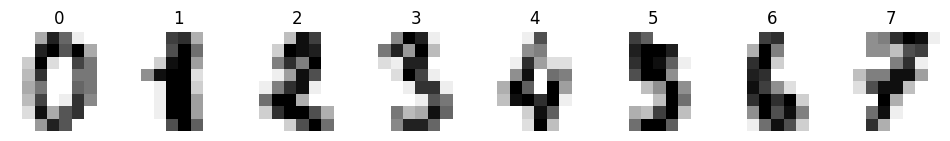

In [6]:
digits = load_digits()
X_dig, y_dig = digits.data, digits.target
print("Shape of the data:", X_dig.shape, "(images x pixels)")

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, lab in zip(axes, digits.images, digits.target):
    ax.imshow(img, cmap="gray_r"); ax.set_title(lab); ax.axis("off")
plt.show()

80% of the variance needs 13 components (out of 64)
90% of the variance needs 21 components (out of 64)
95% of the variance needs 29 components (out of 64)


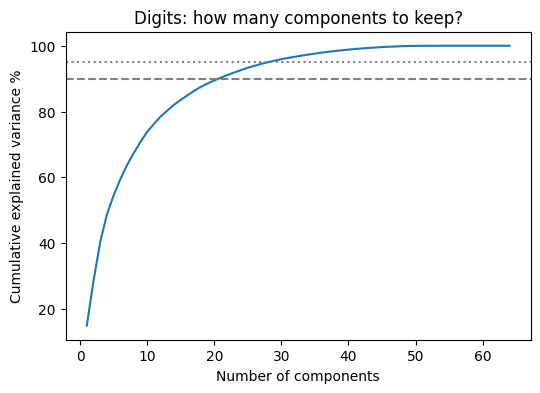

In [7]:
# how many components do we need to keep most of the information?
pca_dig = PCA().fit(X_dig)           # pixels are all on the same scale (0-16), so no standardizing needed
cum = np.cumsum(pca_dig.explained_variance_ratio_)

for target in [0.80, 0.90, 0.95]:
    print(f"{int(target*100)}% of the variance needs {np.argmax(cum >= target) + 1} components (out of 64)")

plt.figure(figsize=(6, 4))
plt.plot(range(1, 65), cum * 100)
plt.axhline(90, color="gray", linestyle="--"); plt.axhline(95, color="gray", linestyle=":")
plt.xlabel("Number of components"); plt.ylabel("Cumulative explained variance %")
plt.title("Digits: how many components to keep?")
plt.show()

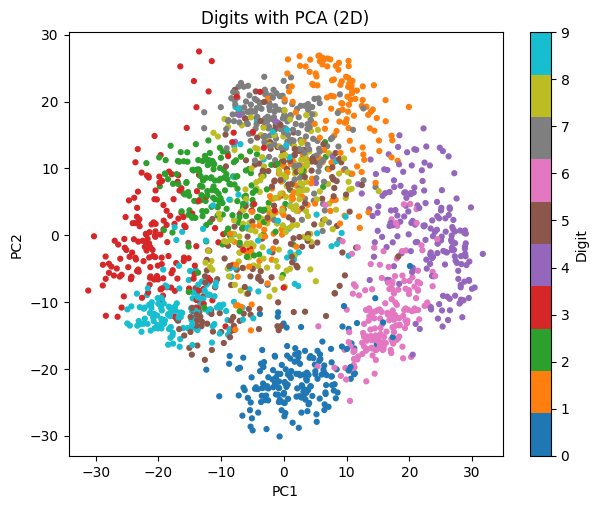

In [8]:
# the 64D data squeezed to just 2 numbers per image
X_dig_pca = PCA(n_components=2).fit_transform(X_dig)

plt.figure(figsize=(7, 5.5))
sc = plt.scatter(X_dig_pca[:, 0], X_dig_pca[:, 1], c=y_dig, cmap="tab10", s=12)
plt.colorbar(sc, label="Digit"); plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Digits with PCA (2D)")
plt.show()

With only 2 components, some digits are separated but many overlap. PCA can only use straight-line projections, and 2 components keep only a small part of the variance (see above).

### Reconstruction: how much do we lose?
We can go back from fewer components to the full 64 pixels (`inverse_transform`). The fewer components we keep, the blurrier the image.

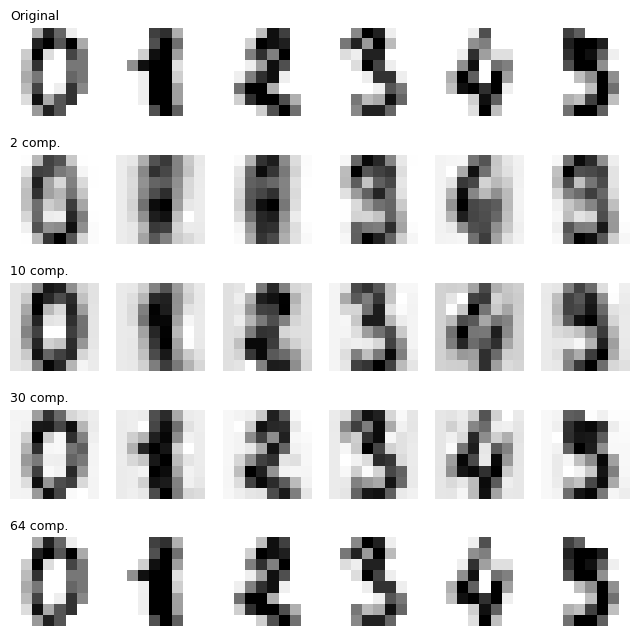

In [9]:
sizes = [2, 10, 30, 64]
fig, axes = plt.subplots(len(sizes) + 1, 6, figsize=(8, 8))
for col in range(6):
    axes[0, col].imshow(X_dig[col].reshape(8, 8), cmap="gray_r"); axes[0, col].axis("off")
for row, k in enumerate(sizes, start=1):
    p = PCA(n_components=k).fit(X_dig)
    rebuilt = p.inverse_transform(p.transform(X_dig[:6]))
    for col in range(6):
        axes[row, col].imshow(rebuilt[col].reshape(8, 8), cmap="gray_r"); axes[row, col].axis("off")
    axes[row, 0].set_title(f"{k} comp.", fontsize=9, loc="left")
axes[0, 0].set_title("Original", fontsize=9, loc="left")
plt.show()

### Application: speed up a model
Instead of feeding 64 pixels to a classifier, feed only the top k components. We check how accuracy changes.
(PCA is inside the pipeline, so it is learned from the training data only.)

In [10]:
Xtr, Xte, ytr, yte = train_test_split(X_dig, y_dig, test_size=0.25, random_state=0, stratify=y_dig)
rows = []
for k in [2, 5, 10, 20, 30, 64]:
    model = make_pipeline(PCA(n_components=k), LogisticRegression(max_iter=3000)).fit(Xtr, ytr)
    rows.append({"Components kept": k, "Test accuracy": round(model.score(Xte, yte), 3)})
pd.DataFrame(rows)

,Components kept,Test accuracy
0,2,0.589
1,5,0.853
2,10,0.947
3,20,0.962
4,30,0.962
5,64,0.964


**Observation:** accuracy rises quickly and then levels off. A small number of components gives almost the same accuracy as all 64 pixels, so we can train on much less data.

### Limitations of PCA
- Only finds **linear** structure (curved or twisted data is not captured well)
- Components are mixtures of features, so they are harder to explain
- Sensitive to scale, so always standardize when features have different units

## 3. t-SNE (t-distributed Stochastic Neighbor Embedding)

### Intuition
t-SNE is made for **visualization**. The idea in simple words:
1. In the original high-dimensional space, work out for every point **who its close neighbours are** (as probabilities).
2. Place the points randomly in 2D.
3. Move the points around step by step so that **neighbours in the high-dimensional space stay neighbours in 2D**, and far points stay far.

It does this by minimizing the difference (KL divergence) between the neighbour probabilities in high-D and in 2D.
The "t" means a heavy-tailed t-distribution is used in 2D, which stops points from getting crushed together and gives clear clusters.

**Perplexity** is the main setting. Roughly, it is "how many neighbours each point pays attention to" (usually 5 to 50).

### t-SNE on Digits (64D -> 2D)
This takes a few seconds.

t-SNE took 7.8 seconds


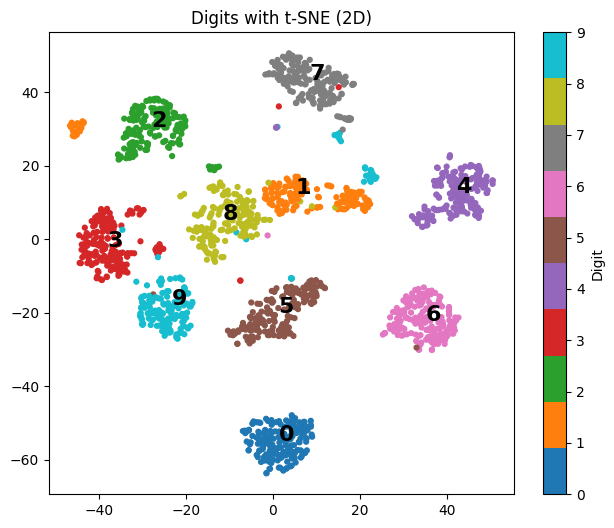

In [11]:
start = time.time()
X_dig_tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=0).fit_transform(X_dig)
print("t-SNE took", round(time.time() - start, 1), "seconds")

plt.figure(figsize=(7.5, 6))
sc = plt.scatter(X_dig_tsne[:, 0], X_dig_tsne[:, 1], c=y_dig, cmap="tab10", s=12)
for d in range(10):                      # write the digit at the centre of its cluster
    cx, cy = np.median(X_dig_tsne[y_dig == d], axis=0)
    plt.text(cx, cy, str(d), fontsize=16, weight="bold")
plt.colorbar(sc, label="Digit")
plt.title("Digits with t-SNE (2D)")
plt.show()

**Observation:** compared with PCA, the ten digits form clear, separate clusters. t-SNE is *non-linear*, so it can unfold the twisted structure that a straight projection cannot.

### Effect of perplexity
Small perplexity looks only at very close neighbours (many small fragments). Large perplexity looks at a wider area. Using 1000 images to keep it quick.

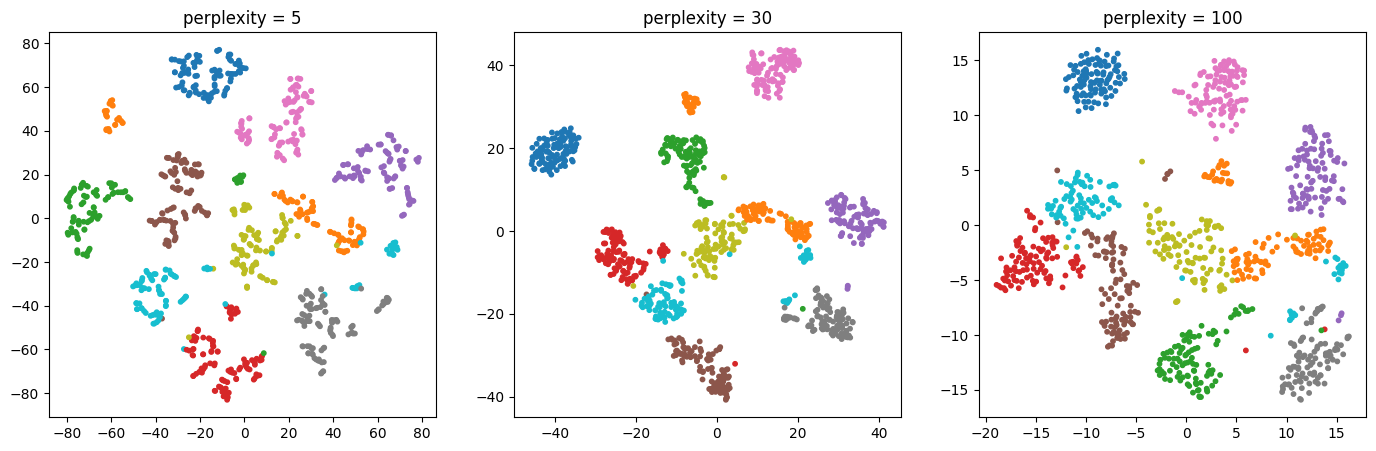

In [12]:
subset = slice(0, 1000)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, perp in zip(axes, [5, 30, 100]):
    emb = TSNE(n_components=2, perplexity=perp, init="pca", random_state=0).fit_transform(X_dig[subset])
    ax.scatter(emb[:, 0], emb[:, 1], c=y_dig[subset], cmap="tab10", s=10)
    ax.set_title(f"perplexity = {perp}")
plt.show()

### Things to remember when reading a t-SNE plot
- **Clusters are meaningful** (points in a cluster are similar).
- **Distances between clusters and cluster sizes are NOT meaningful.** Do not read "this cluster is twice as far".
- The result changes with `perplexity` and with the random seed, so try several values.
- It is slow on big datasets and it cannot transform new data (there is no `transform`, only `fit_transform`).
- Use it for **visualization only**, not as input features for a model.

## 4. PCA vs t-SNE side by side

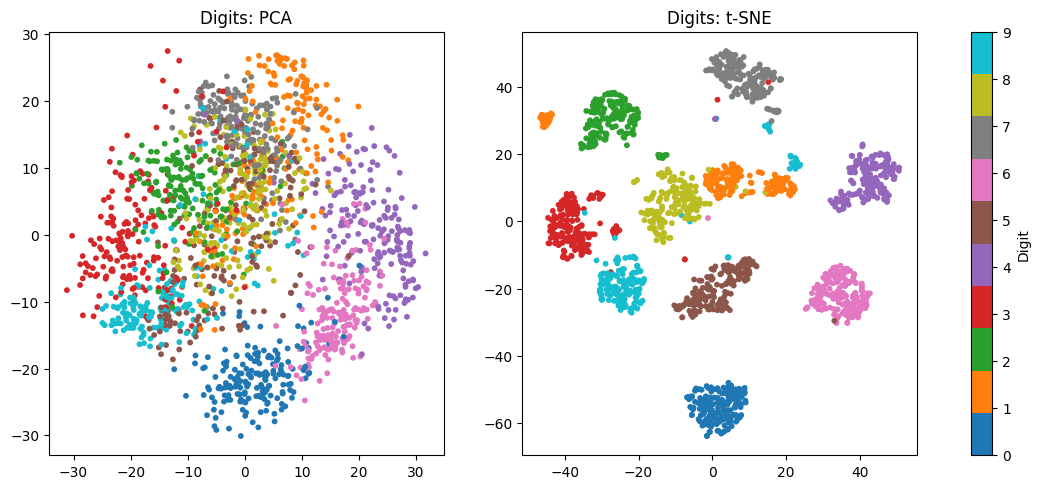

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, emb, title in zip(axes, [X_dig_pca, X_dig_tsne], ["PCA", "t-SNE"]):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=y_dig, cmap="tab10", s=10)
    ax.set_title(f"Digits: {title}")
fig.colorbar(sc, ax=axes, label="Digit")
plt.show()

| | PCA | t-SNE |
|---|---|---|
| Type | Linear | Non-linear |
| Main goal | Keep as much variance as possible | Keep neighbours close (visualization) |
| Speed | Very fast | Slow on large data |
| Same result every run? | Yes | No (depends on seed and perplexity) |
| Can transform new data? | Yes | No |
| Distances in the plot | Meaningful | Only local neighbourhoods are meaningful |
| Components explainable? | Yes (loadings) | No |
| Good for | Preprocessing, noise removal, compression, speeding up models | Exploring clusters in complex data |

## 5. Applications

| Application | Technique | Example |
|---|---|---|
| Visualizing high-dimensional data | PCA / t-SNE | Plot 64-pixel images as 2D points |
| Speeding up machine learning models | PCA | Train on 20 components instead of 64 pixels |
| Noise removal | PCA | Drop low-variance components, then reconstruct |
| Image compression | PCA | Store fewer numbers per image |
| Exploring clusters / checking if classes separate | t-SNE | See if digit classes form groups |
| Gene expression and bioinformatics | PCA, t-SNE | Thousands of genes down to 2D |
| Word embeddings | t-SNE | Show similar words close together |
| Removing correlated features | PCA | Features like height and weight overlap |

## Conclusion
- Dimensionality reduction squeezes many features into a few, so we can **visualize** the data and make models **faster**.
- **PCA** is a fast, linear method that keeps the maximum variance. Good for preprocessing and compression.
- **t-SNE** is a non-linear method that keeps neighbourhoods. Good for visualization, but not for features, and the plot must be read carefully.
- A common workflow: reduce with PCA first (e.g. to 30 components), then run t-SNE on the result.